In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


TASK 1

In [4]:
df = pd.read_csv("housing.csv")

print("Dataset Shape:", df.shape)
print("\nFirst Five Rows:")
print(df.head())

Dataset Shape: (20640, 10)

First Five Rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


TASK 2

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())


Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Basic Statistics:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  

TASK 3

In [ ]:

df.fillna(df.median(numeric_only=True), inplace=True)


X1 = df[['total_bedrooms']]
y = df['median_house_value']


X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)


TASK 4

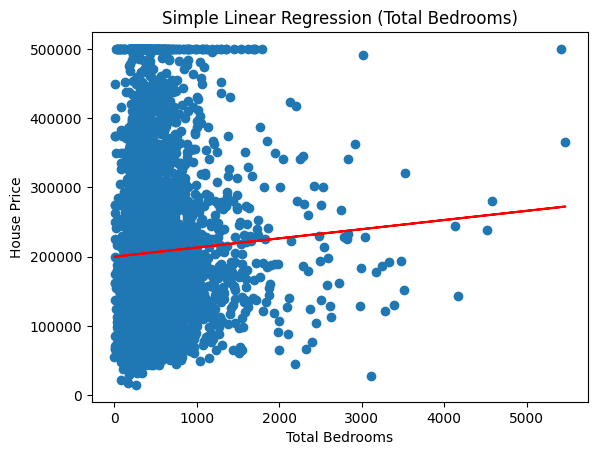

In [20]:
plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred1, color='red')
plt.title("Simple Linear Regression (Total Bedrooms)")
plt.xlabel("Total Bedrooms")
plt.ylabel("House Price")
plt.show()

TASK 5

In [21]:
mse1 = mean_squared_error(y_test, y_pred1)
mae1 = mean_absolute_error(y_test, y_pred1)
rmse1 = np.sqrt(mse1)

print("\nModel 1 Metrics:")
print("MSE:", mse1)
print("MAE:", mae1)
print("RMSE:", rmse1)
print("R2 Score:", r2_score(y_test, y_pred1))


Model 1 Metrics:
MSE: 13067257463.21339
MAE: 90374.96676570243
RMSE: 114312.10549724552
R2 Score: 0.002810749911455246


TASK 6

In [22]:
X2 = df[['total_rooms']]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

mse2 = mean_squared_error(y_test2, y_pred2)
mae2 = mean_absolute_error(y_test2, y_pred2)
rmse2 = np.sqrt(mse2)

print("\nModel 2 Metrics:")
print("MSE:", mse2)
print("MAE:", mae2)
print("RMSE:", rmse2)
print("R2 Score:", r2_score(y_test2, y_pred2))


Model 2 Metrics:
MSE: 12868608472.627417
MAE: 89419.4255544871
RMSE: 113439.88924812742
R2 Score: 0.017970062300526446


TASK 7

In [23]:

X_multi2 = df[['total_bedrooms', 'total_rooms']]

X_train_m2, X_test_m2, y_train_m2, y_test_m2 = train_test_split(X_multi2, y, test_size=0.2, random_state=42)

multi_model2 = LinearRegression()
multi_model2.fit(X_train_m2, y_train_m2)

y_pred_m2 = multi_model2.predict(X_test_m2)

mse_m2 = mean_squared_error(y_test_m2, y_pred_m2)
mae_m2 = mean_absolute_error(y_test_m2, y_pred_m2)
rmse_m2 = np.sqrt(mse_m2)

print("\nMultiple Regression (2 Features) Metrics:")
print("MSE:", mse_m2)
print("MAE:", mae_m2)
print("RMSE:", rmse_m2)
print("R2 Score:", r2_score(y_test_m2, y_pred_m2))


Multiple Regression (2 Features) Metrics:
MSE: 12570882702.52496
MAE: 87890.551625022
RMSE: 112119.94783500819
R2 Score: 0.040690127184554115


TASK 8

In [26]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)


X_all = df.drop(columns=['median_house_value'])

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y, test_size=0.2, random_state=42)

multi_model_all = LinearRegression()
multi_model_all.fit(X_train_all, y_train_all)

y_pred_all = multi_model_all.predict(X_test_all)

mse_all = mean_squared_error(y_test_all, y_pred_all)
mae_all = mean_absolute_error(y_test_all, y_pred_all)
rmse_all = np.sqrt(mse_all)

print("\nMultiple Regression (All Features) Metrics:")
print("MSE:", mse_all)
print("MAE:", mae_all)
print("RMSE:", rmse_all)
print("R2 Score:", r2_score(y_test_all, y_pred_all))


Multiple Regression (All Features) Metrics:
MSE: 4908476721.156625
MAE: 50670.7382409721
RMSE: 70060.52184473525
R2 Score: 0.6254240620553599


TASK 9

In [27]:
print("\nFINAL COMPARISON")
print("Simple Model 1 RMSE:", rmse1)
print("Simple Model 2 RMSE:", rmse2)
print("Multiple (2 Features) RMSE:", rmse_m2)
print("Multiple (All Features) RMSE:", rmse_all)


FINAL COMPARISON
Simple Model 1 RMSE: 114312.10549724552
Simple Model 2 RMSE: 113439.88924812742
Multiple (2 Features) RMSE: 112119.94783500819
Multiple (All Features) RMSE: 70060.52184473525
